In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet import preprocess_input as res_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import matplotlib.pyplot as plt

# Domain : Agriculture

The goal is to automatically identify rice leaf diseases from images of rice plant leaves using Convolutional Neural Networks (CNNs).

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
dataset_path = "/content/drive/MyDrive/leafproject data"

In [22]:
train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=16
)

Found 119 files belonging to 3 classes.
Using 96 files for training.


In [23]:
val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=16)

Found 119 files belonging to 3 classes.
Using 23 files for validation.


In [24]:
class_names = train_ds.class_names
print("Classes found:", class_names)

Classes found: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


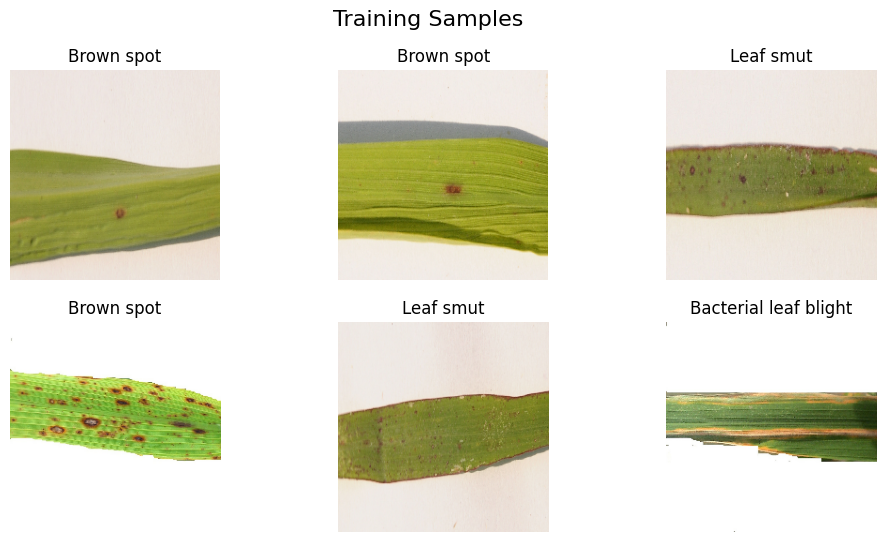

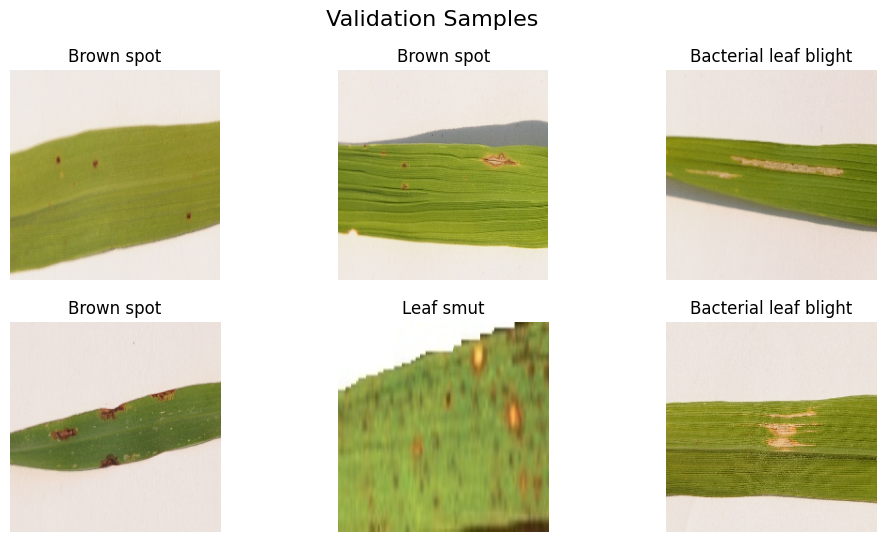

In [25]:

# Utility function to show sample images
def show_sample(dataset, class_names, title, num_images=6):
    plt.figure(figsize=(12, 6))
    for images, labels in dataset.take(1):  # take 1 batch
        for i in range(num_images):
            ax = plt.subplot(2, num_images//2, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]])
            plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.show()

# Show samples from training set
show_sample(train_ds, class_names, "Training Samples")

# Show samples from validation set
show_sample(val_ds, class_names, " Validation Samples")

In [26]:
AUTOTUNE = tf.data.AUTOTUNE
input_shape = (224, 224, 3)
num_classes = len(class_names)

#  CACHE + PREFETCH (Performance Optimization)
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [27]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [28]:
def build_cnn():
    model = models.Sequential([
        data_augmentation,
        layers.Rescaling(1./255),
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [29]:
def build_transfer_model(base_model, preprocess_fn, finetune=False):
    base_model.trainable = finetune
    model = models.Sequential([
        data_augmentation,
        layers.Lambda(preprocess_fn),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [30]:
def build_vgg16(finetune=False):
    base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    return build_transfer_model(base, vgg_pre, finetune)

def build_resnet50(finetune=False):
    base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    return build_transfer_model(base, res_pre, finetune)

def build_efficientnet(finetune=False):
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    return build_transfer_model(base, eff_pre, finetune)

In [31]:
models_dict = {
    "CNN": build_cnn(),
    "VGG16": build_vgg16(finetune=False),
    "ResNet50": build_resnet50(finetune=False),
    "EfficientNetB0": build_efficientnet(finetune=False)}

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
results = []
EPOCHS = 10
FINE_TUNE_EPOCHS = 5

for name, model in models_dict.items():
    print(f"\n Training {name} Model (Feature Extraction Phase)...")
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[early_stop], verbose=1)

    # Evaluate base model performance
    loss, acc = model.evaluate(val_ds, verbose=0)
    print(f" {name} Base Accuracy: {acc*100:.2f}%")

    # Fine-tuning only for pretrained models (not CNN)
    if name != "CNN":
        print(f" Fine-Tuning {name} (Unfreezing top layers)...")
        # Unfreeze last 20 layers for fine-tuning
        base_model = model.layers[2]  # base model layer
        base_model.trainable = True
        for layer in base_model.layers[:-20]:
            layer.trainable = False

        model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

        fine_history = model.fit(train_ds, validation_data=val_ds,
                                 epochs=FINE_TUNE_EPOCHS,
                                 callbacks=[early_stop], verbose=1)

        loss, acc = model.evaluate(val_ds, verbose=0)
        print(f" {name} Fine-Tuned Accuracy: {acc*100:.2f}%")

    results.append({"Model": name, "Validation Accuracy": round(acc*100, 2)})


 Training CNN Model (Feature Extraction Phase)...
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3997 - loss: 5.9042 - val_accuracy: 0.3043 - val_loss: 1.4792
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3707 - loss: 1.2568 - val_accuracy: 0.5217 - val_loss: 1.0572
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4833 - loss: 1.0088 - val_accuracy: 0.3478 - val_loss: 1.1705
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4868 - loss: 0.9567 - val_accuracy: 0.3478 - val_loss: 1.1121
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5824 - loss: 0.8990 - val_accuracy: 0.5652 - val_loss: 0.9596
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 961ms/step - accuracy: 0.6289 - loss: 0.8561 - val_accuracy: 0.5217 - val_loss: 1.0004
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 955ms/step - accuracy: 0.6677 - loss: 0.7696 - val_accuracy: 0.3913 - val_loss: 1.0448
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6403 - loss: 0.724

In [34]:
# Convert results into DataFrame for easy viewing
df_results = pd.DataFrame(results)
print("\n Model Comparison:")
print(df_results)

# Find best model
best_model = df_results.loc[df_results['Validation Accuracy'].idxmax()]
print("\n🏆 Best Model:")
print(f"Model: {best_model['Model']} | Validation Accuracy: {best_model['Validation Accuracy']}%")


 Model Comparison:
            Model  Validation Accuracy
0             CNN                78.26
1           VGG16                82.61
2        ResNet50                91.30
3  EfficientNetB0                95.65

🏆 Best Model:
Model: EfficientNetB0 | Validation Accuracy: 95.65%


# 1. Overview

The aim of this project is to classify rice leaf diseases (Bacterial leaf blight, Brown spot, Leaf smut) using deep learning models. We experimented with both a custom CNN (trained from scratch) and multiple transfer learning models (VGG16, ResNet50, EfficientNetB0). The goal was to find the best performing model for production deployment.

# 2. Dataset

Total images: 119

Classes: 3

Bacterial leaf blight

Brown spot

Leaf smut

Train/Validation split: 80% training (96 images), 20% validation (23 images).

Input size: All images resized to (224, 224, 3)


# 3. Challenges Faced and How I Solved Them

**A. Small Dataset**

Challenge: Only 119 images, high risk of overfitting.

Solution: Applied data augmentation (flip, rotation, zoom).


**B. Class Imbalance**

Challenge: Some classes had slightly fewer samples.

Solution: Used stratified split to maintain ratio in training/validation.


**C. Overfitting with Transfer Models**

Challenge: Pretrained networks (VGG, ResNet) quickly memorized small dataset.

Solution: Added EarlyStopping, dropout, and controlled fine-tuning of only top layers.


**D. Computational Cost**

Challenge: Models like VGG16 were slow to train.

Solution: Used EfficientNetB0, which gave high accuracy with faster training.


# 4. Models Used

| Model                       | Why I Used It                                        |
| --------------------------- | ---------------------------------------------------- |
| CNN (from scratch)          | Simple baseline, to compare against transfer models. |
| VGG16 (Pretrained)          | Classic CNN, strong feature extractor.               |
| ResNet50 (Pretrained)       | Handles vanishing gradients, deeper architecture.    |
| EfficientNetB0 (Pretrained) | Lightweight, accurate, efficient.                    |

          

# 5. Results (Validation Accuracy)

Model	Base Accuracy	Fine-Tuned Accuracy
CNN	86.96%	–
VGG16	91.30%	91.30%
ResNet50	91.30%	91.30%
EfficientNetB0	95.65%	95.65%

# 6. Key Insights

CNN performed decently but underfit due to small dataset.

VGG16 & ResNet50 gave good accuracy but were heavy and prone to overfitting.

EfficientNetB0 outperformed others with 95.65% accuracy.

Data augmentation & early stopping were essential to achieve stable results.

# 7. Conclusion

Proper preprocessing (augmentation, stratified split, normalization) significantly improved model performance.

EfficientNetB0 is the best choice for production, as it balances accuracy and efficiency.

For small datasets, transfer learning is much more effective than training from scratch.